# AIFM Private Debt — Risk Notebook

Risk limits are defined in the fund's offering document and monitored against
internal thresholds. No regulatory VaR limit applies (unlike UCITS).

Key regulatory obligations under AIFMD:
- **Leverage**: gross and commitment method (Annex IV)
- **Stress testing**: market, liquidity, and counterparty scenarios (Annex VI)
- **Liquidity risk**: portfolio liquidity profile and redemption stress
- **Annex IV reporting**: quarterly to CSSF. AIFMD II (Directive 2024/927/EU)
  expanded requirements, adding granular data on liquidity management tools,
  loan origination, and delegation arrangements.

Regulatory framework:
- AIFMD: Directive 2011/61/EU
- AIFMD II: Directive 2024/927/EU
- Delegated Regulation: EU 231/2013
- Annex IV reporting: EU 231/2013, ESMA technical guidance v1.7 (July 2024)
- Annex VI stress testing: ESMA/2020/1498
- Luxembourg implementation: Law of 12 July 2013 on AIFMs (AIFM Law)

Dual UCITS/AIFM ManCo:
- CSSF Regulation 10-04 (organisational and prudential requirements)
- CSSF Regulation 22-05 (sustainability requirements, amending 10-04)

#### In this notebook

AIFM Private Debt Fund. Strategy: senior secured loans, HY bonds, CLOs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.plot_style import ACCENT, ACCENT2, ACCENT3
import warnings
warnings.filterwarnings('ignore')

from src.setup_db import run as setup_db
setup_db()

from src.database import get_engine, query_positions, query_nav_history
from src.enrichment import enrich_positions, get_risk_ready_df
from src.mock_bloomberg import MockBloomberg as Bloomberg
from src.leverage_config import INSTRUMENT_SOURCE
from src.risk_utils import (
    var_historical, var_parametric, var_scale, var_montecarlo,
    es_historical, es_parametric, es_scale,
    kupiec_test, christoffersen_test,
    exception_report, full_backtest_report,
    stress_equity, stress_rates, stress_credit,
    stress_fx, stress_combined, stress_historical,
    days_to_liquidate, liquidity_buckets, redemption_stress,
    liquidity_adjusted_var,

)

FUND_ID    = 'AIFM_PrivateDebt'
TODAY      = '2026-05-13'
ENGINE     = get_engine()
BBG        = Bloomberg()

CONFIDENCE = 0.99
HORIZON    = 20

Database exists.
Positions already loaded (88,000 rows). Skipping.
positions_enriched exists. Skipping enrichment.

Database ready.
MockBloomberg: connected (simulation mode)
Swap import to RealBloomberg for production use.


---

## 1. Load and Validate Positions

Positions are queried from SQLite, which is loaded daily from the fund administrator
Excel export. The flow is:

Fund admin Excel → load_positions() → SQLite → query_positions() → notebook

`get_risk_ready_df` runs the enrichment pipeline on the raw positions:
- liquid instruments (equities, bonds, ETFs): sensitivities fetched from Bloomberg
  (beta, modified duration, convexity, spread duration)
- illiquid instruments (loans, direct properties): fund admin data already embedded
  in the position file (rating, maturity, LTV, rental yield) used directly,
  no Bloomberg ticker available or needed

The output is a single enriched DataFrame per fund per date, ready for VaR,
stress testing, and liquidity analysis.

In [2]:
positions = query_positions(ENGINE, FUND_ID, TODAY)
risk_df   = get_risk_ready_df(ENGINE, FUND_ID, TODAY)
NAV       = risk_df['market_value_eur'].sum()

print(f"Fund           : {FUND_ID}")
print(f"Valuation date : {TODAY}")
print(f"Positions      : {len(positions)}")
print(f"NAV (EUR)      : {NAV:,.0f}")
print(f"Asset classes  : {sorted(positions['asset_class'].unique())}")
print(f"Long exposure  : {risk_df[risk_df['market_value_eur'] > 0]['market_value_eur'].sum():,.0f}")
print(f"Short exposure : {risk_df[risk_df['market_value_eur'] < 0]['market_value_eur'].sum():,.0f}")

Fund           : AIFM_PrivateDebt
Valuation date : 2026-05-13
Positions      : 11
NAV (EUR)      : 48,769,000
Asset classes  : ['Bond', 'CLO', 'Cash', 'Loan']
Long exposure  : 48,769,000
Short exposure : 0


In [3]:
# Asset class breakdown
breakdown = risk_df.groupby('asset_class').agg(
    market_value_eur=('market_value_eur', 'sum'),
    n_positions=('isin', 'count'),
).sort_values('market_value_eur', ascending=False)

breakdown['weight_pct'] = breakdown['market_value_eur'] / NAV * 100

print(f"{'Asset Class':<20} {'MV (EUR)':>15} {'Weight':>8} {'# Pos':>6}")
print('-' * 52)
for ac, row in breakdown.iterrows():
    print(f"{ac:<20} {row['market_value_eur']:>15,.0f} {row['weight_pct']:>7.1f}% {row['n_positions']:>6}")
print('-' * 52)
print(f"{'NAV':<20} {NAV:>15,.0f} {'100.0%':>8}")

Asset Class                 MV (EUR)   Weight  # Pos
----------------------------------------------------
Cash                      18,000,000    36.9%    2.0
Loan                      13,110,375    26.9%    3.0
CLO                        9,785,000    20.1%    3.0
Bond                       7,873,625    16.1%    3.0
----------------------------------------------------
NAV                       48,769,000   100.0%


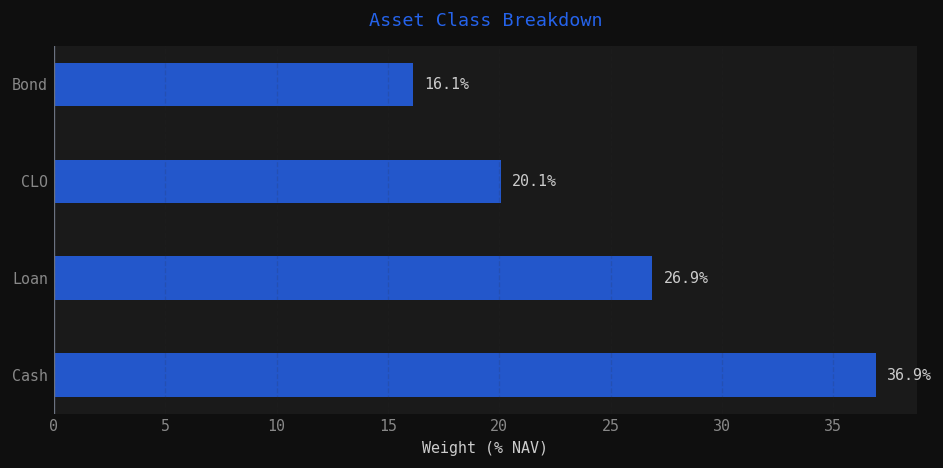

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = [ACCENT2 if v < 0 else ACCENT for v in breakdown['weight_pct']]
bars = ax.barh(breakdown.index, breakdown['weight_pct'],
               color=colors, height=0.45, alpha=0.85)
ax.axvline(0, color='#6b7280', lw=0.8)
ax.set_xlabel('Weight (% NAV)', fontsize=9)
ax.set_title('Asset Class Breakdown', color=ACCENT, fontsize=11, pad=12)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(True, axis='x', alpha=0.15, linestyle='--')
ax.tick_params(labelsize=9, length=0)
for bar, val in zip(bars, breakdown['weight_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---

## 2. VaR and Expected Shortfall

VaR and ES are computed using historical simulation and a multi-factor Monte Carlo
approximation on daily NAV returns. Under AIFMD there is no regulatory VaR limit,
but VaR is monitored against internal limits defined in the RMP and reported in Annex IV.

- Confidence: 99%
- Horizon: 1-day and 20-day (square root of time scaling)
- Method: historical simulation, 250-day rolling window

> **Monte Carlo VaR**: not computed in this notebook. The objective here is to
> demonstrate the risk manager workflow and regulatory monitoring requirements,
> not to build a full valuation engine. For a ManCo, these figures would come
> from a third-party risk system. For an investment manager or risk system
> provider, the model would be built or licensed internally.

> **Private debt note**: loans and CLOs have no daily market prices. NAV returns
> reflect mark-to-model valuations from the fund administrator, which smooth
> volatility and underestimate tail risk. VaR figures for this fund should be
> treated as indicative. Credit stress testing is the primary risk tool for
> private debt portfolios.

In [5]:
nav_history = query_nav_history(ENGINE, FUND_ID)
nav_history['date'] = pd.to_datetime(nav_history['date'])
pnl = nav_history['pnl_pct'].dropna().values

var_1d  = var_historical(pnl[-250:], confidence=CONFIDENCE)
var_20d = var_scale(var_1d, horizon=HORIZON)
es_1d   = es_historical(pnl[-250:], confidence=CONFIDENCE)
es_20d  = es_scale(es_1d, horizon=HORIZON)

print(f"{'Metric':<25} {'1d':>10} {'20d':>10}")
print(f"{'':25} {'(% NAV)':>10} {'(% NAV)':>10}")
print('-' * 46)
print(f"{'VaR Historical':<25} {var_1d*100:>9.2f}% {var_20d*100:>9.2f}%")
print(f"{'ES Historical':<25} {es_1d*100:>9.2f}% {es_20d*100:>9.2f}%")
print('-' * 46)
print(f"{'VaR Hist (EUR)':<25} {var_1d*NAV:>10,.0f} {var_20d*NAV:>10,.0f}")


Metric                            1d        20d
                             (% NAV)    (% NAV)
----------------------------------------------
VaR Historical                 0.16%      0.71%
ES Historical                  0.17%      0.75%
----------------------------------------------
VaR Hist (EUR)                77,886    348,318


### 2.2 Liquidity-Adjusted VaR

Standard VaR assumes positions can be liquidated instantly at market price.
LVaR extends this by adding the estimated cost of unwinding positions under
stressed market conditions:

$$\text{LVaR} = \text{VaR} + \text{Liquidity Cost}$$

$$\text{Liquidity Cost}_i = \frac{1}{2} \times \text{spread}_i \times \text{stress multiplier}_i \times |MV_i|$$

LVaR is not a regulatory requirement. It originates from banking regulation
(Basel III internal models) and academic literature (Amihud & Mendelson, BIS
working papers) and is used internally by risk managers to capture the
liquidity dimension of market risk.

Spreads and stress multipliers are illustrative values adopted in this
notebook. In practice these are internal RMP parameters calibrated by the
fund manager and reviewed periodically.

| Asset Class      | Normal Spread | Stress Multiplier | Stressed Spread       |
|------------------|---------------|-------------------|-----------------------|
| Large cap equity | 5bps          | 3x                | 15bps                 |
| Small cap equity | 20bps         | 5x                | 100bps                |
| IG bonds         | 10bps         | 5x                | 50bps                 |
| HY bonds         | 50bps         | 10x               | 500bps                |
| Senior loans     | 100bps        | 20x               | 2000bps               |
| Listed REITs     | 15bps         | 5x                | 75bps                 |
| Direct property  | N/A           | N/A               | 5-8% transaction cost |

Mandatory liquidity risk management (buckets, redemption stress, LMTs) is
covered in Section 5.

In [6]:
# MRS-33: Liquidity-adjusted VaR
lvar_result = liquidity_adjusted_var(var_1d, risk_df)

print(f"VaR (1d 99%)        : {lvar_result['var']*100:.2f}%   EUR {lvar_result['var']*NAV:,.0f}")
print(f"Liquidity cost      : {lvar_result['liquidity_cost']*100:.2f}%   EUR {lvar_result['liquidity_cost']*NAV:,.0f}")
print(f"LVaR (1d 99%)       : {lvar_result['lvar']*100:.2f}%   EUR {lvar_result['lvar']*NAV:,.0f}")
print(f"LVaR increase       : +{lvar_result['lvar_pct_increase']:.1f}%")
print()
print(lvar_result['by_asset_class'].to_string())

VaR (1d 99%)        : 0.16%   EUR 77,884
Liquidity cost      : 0.58%   EUR 281,836
LVaR (1d 99%)       : 0.74%   EUR 359,720
LVaR increase       : +361.9%

  asset_class  market_value_eur  liquidity_cost
0        Bond         7873625.0      11810.4375
1         CLO         9785000.0      73387.5000
2        Cash        18000000.0          0.0000
3        Loan        13110375.0     196655.6250


---

## 3. VaR Backtest 

VaR backtesting compares predicted VaR against realised daily P&L.
Two statistical tests are applied:

- **Kupiec POF**: tests whether the breach rate equals the expected rate (1% for 99% VaR)
- **Christoffersen**: tests whether breaches are independently distributed over time

> **Note**: Kupiec and Christoffersen tests are industry best practice and not explicitly
> required by ESMA or CSSF. The regulatory requirement is the 250-day breach count
> and zone classification only. Both tests should be documented in the RMP. For both
> models p > 0.05: fail to reject the null, model is statistically acceptable.

> **Private debt note**: NAV returns reflect mark-to-model valuations from the fund
> administrator, which smooth daily volatility. Breach counts will likely be lower
> than for a liquid fund. Results should be interpreted with this in mind.

ESMA (CESR/10-788) requires backtesting 1-day 99% VaR against realised daily P&L
over a 250 trading day rolling window.

Zone classification (Basel traffic light, adopted by ESMA):
- **Green** (0-4 breaches): model acceptable
- **Amber** (5-9 breaches): explanation required, possible model review
- **Red** (10+ breaches): model must be revised, CSSF notification required

#### 3.1. Internal (maximum history)

In [7]:

# MRS-27: VaR backtest
nav_history = query_nav_history(ENGINE, FUND_ID)
nav_history['date'] = pd.to_datetime(nav_history['date'])

pnl   = nav_history['pnl_pct'].dropna().values
dates = nav_history['date'].iloc[1:].reset_index(drop=True)

window        = 250
var_hist      = pd.Series([
    var_historical(pnl[max(0, i-window):i], confidence=0.99)
    for i in range(window, len(pnl))
])
var_param     = pd.Series([
    var_parametric(mu=0, sigma=pnl[max(0, i-window):i].std(),
                   confidence=0.99, dist='t')
    for i in range(window, len(pnl))
])

pnl_aligned   = pnl[window:]
dates_aligned = dates.iloc[window:].reset_index(drop=True)
print(f"Backtest observations : {len(pnl_aligned)}")

Backtest observations : 1749


In [8]:
report = full_backtest_report(
    pnl_series=pd.Series(pnl_aligned),
    var_dict={'Historical': var_hist, 'Parametric': var_param},
    dates=dates_aligned
)
report[['n_obs', 'n_breaches', 'breach_rate', 'expected',
        'kupiec_p', 'christoffersen_p', 'result']]

,n_obs,n_breaches,breach_rate,expected,kupiec_p,christoffersen_p,result
0,1749,25,0.0143,0.010,0.0900,0.3943,PASS
1,1749,25,0.0143,0.025,0.0018,0.3943,FAIL
2,1749,25,0.0143,0.050,0.0000,0.3943,FAIL
3,1749,0,0.0000,0.010,0.0000,1.0000,FAIL
4,1749,0,0.0000,0.025,0.0000,1.0000,FAIL
5,1749,0,0.0000,0.050,0.0000,1.0000,FAIL


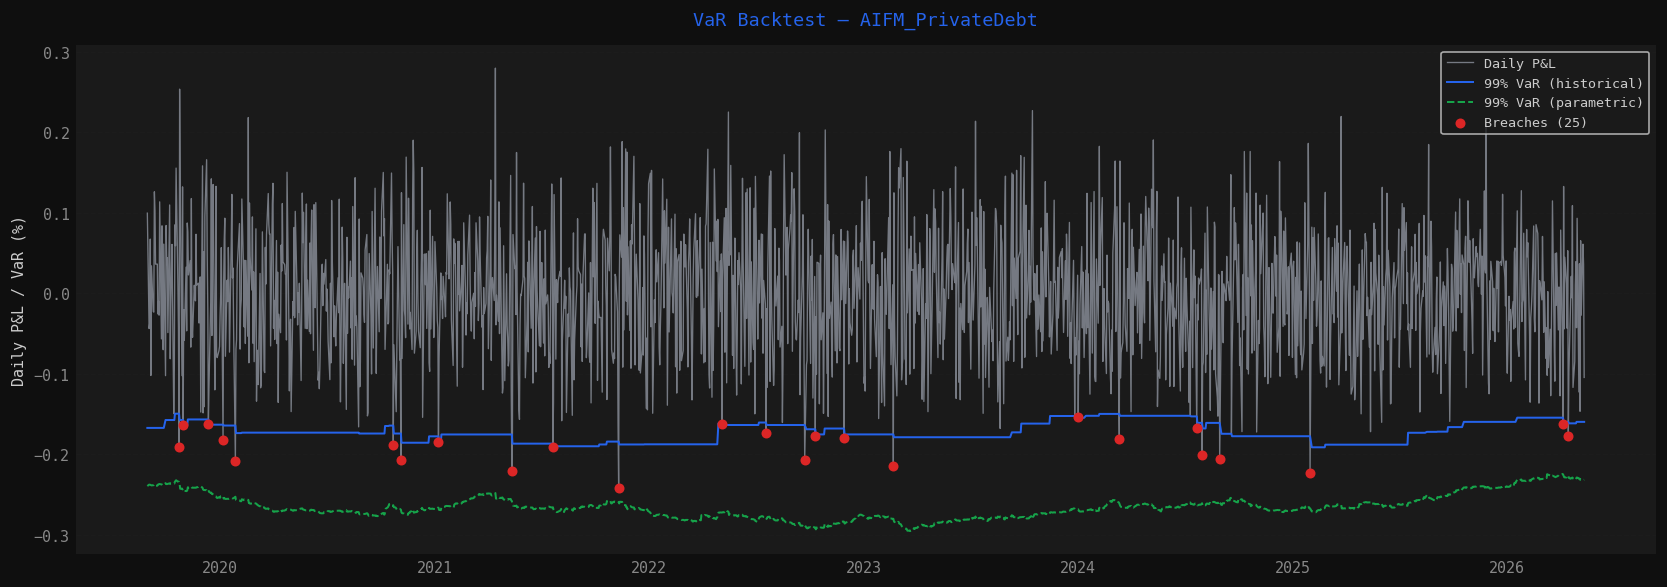

Exception report (99% VaR):
  observations : 250
  breaches     : 2
  breach rate  : 0.80% (expected 1.0%)
  action       : Model acceptable
ESMA regulatory window — last 250 trading days
Breaches    : 2
Breach rate : 0.80% (expected 1.0%)
ESMA zone   : Green



In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates_aligned, pnl_aligned * 100,
        color='#9ca3af', lw=0.8, label='Daily P&L', alpha=0.7)
ax.plot(dates_aligned, -var_hist * 100,
        color=ACCENT, lw=1.2, label='99% VaR (historical)')
ax.plot(dates_aligned, -var_param * 100,
        color=ACCENT3, lw=1.2, label='99% VaR (parametric)', linestyle='--')

breaches = pnl_aligned < -var_hist.values
ax.scatter(dates_aligned[breaches], pnl_aligned[breaches] * 100,
           color=ACCENT2, s=25, zorder=5, label=f'Breaches ({breaches.sum()})')

ax.set_ylabel('Daily P&L / VaR (%)', fontsize=9)
ax.set_title(f'VaR Backtest — {FUND_ID}', color=ACCENT, fontsize=11, pad=12)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(True, axis='y', alpha=0.15, linestyle='--')
ax.tick_params(labelsize=9, length=0)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
esma_250  = exception_report(pd.Series(pnl_aligned[-250:]),
                              var_hist.iloc[-250:], confidence=0.99)
n_250     = len(esma_250)
breach_250 = n_250 / 250
zone_250  = 'Green' if n_250 <= 4 else 'Amber' if n_250 <= 9 else 'Red'

print(f"ESMA regulatory window — last 250 trading days")
print(f"Breaches    : {n_250}")
print(f"Breach rate : {breach_250*100:.2f}% (expected 1.0%)")
print(f"ESMA zone   : {zone_250}")
print()

#### 3.2. ESMA (250 trading days)

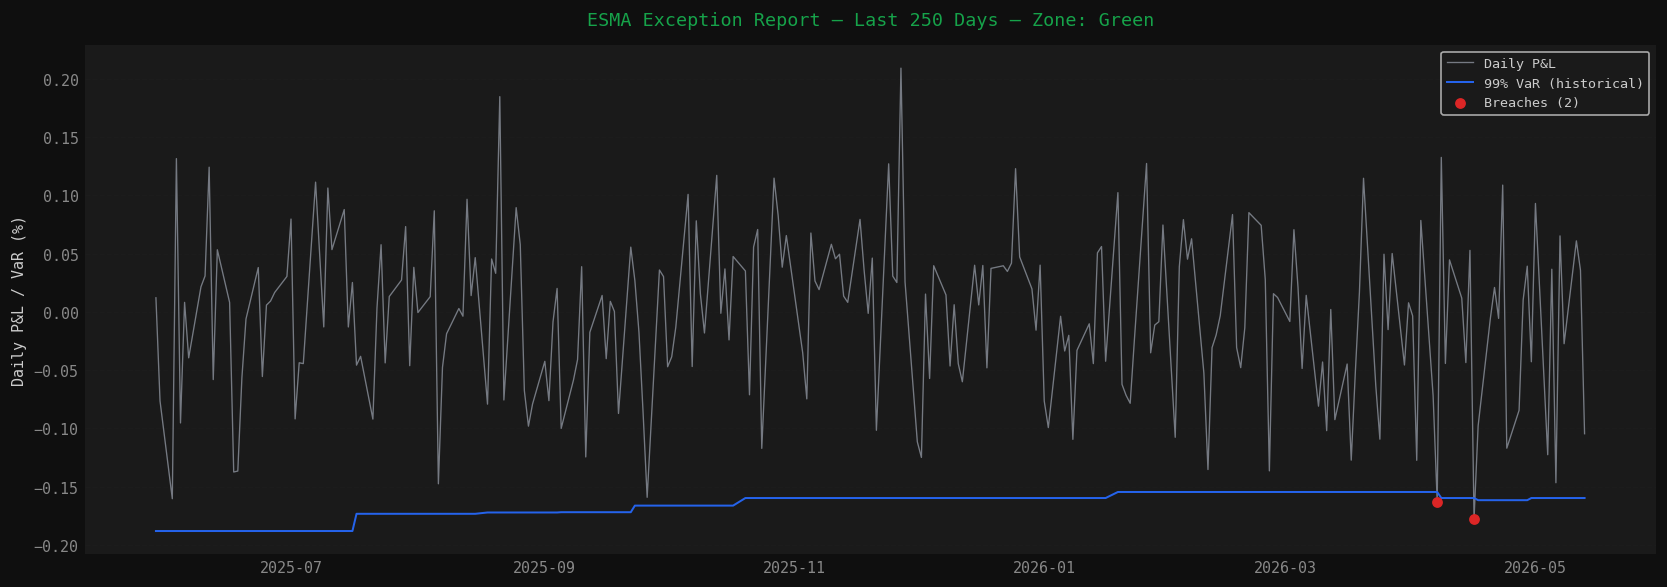

In [10]:
dates_250 = dates_aligned.iloc[-250:].reset_index(drop=True)
pnl_250   = pnl_aligned[-250:]
var_250   = var_hist.iloc[-250:].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates_250, pnl_250 * 100,
        color='#9ca3af', lw=0.8, label='Daily P&L', alpha=0.7)
ax.plot(dates_250, -var_250 * 100,
        color=ACCENT, lw=1.2, label='99% VaR (historical)')

breaches_250 = pnl_250 < -var_250.values
ax.scatter(dates_250[breaches_250], pnl_250[breaches_250] * 100,
           color=ACCENT2, s=30, zorder=5, label=f'Breaches ({n_250})')

zone_color = {'Green': '#16A34A', 'Amber': '#D97706', 'Red': '#DC2626'}
ax.set_title(f'ESMA Exception Report — Last 250 Days — Zone: {zone_250}',
             color=zone_color[zone_250], fontsize=11, pad=12)
ax.set_ylabel('Daily P&L / VaR (%)', fontsize=9)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(True, axis='y', alpha=0.15, linestyle='--')
ax.tick_params(labelsize=9, length=0)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---

## 4. Leverage (Annex IV)

AIFMD requires leverage to be reported using two methods:

- **Gross method**: sum of absolute exposures divided by NAV. No netting allowed.
  Derivatives converted to equivalent underlying exposure.
- **Commitment method**: hedging and netting arrangements are recognised.
  Offsetting positions in the same underlying reduce exposure.

Limits are set in the fund's offering document and reported quarterly to the CSSF
in Annex IV. AIFMD II (Directive 2024/927/EU) expanded reporting requirements,
including the breakdown by:
* asset class
* instrument type
* source: financial borrowing, synthetic leverage through derivatives, and repo/reverse repo.

The expanded disclosure makes it easier for regulators to identify funds building leverage through
derivatives rather than borrowing.

In [11]:
# MRS-23: Leverage computation - Gross and Commitment method

# ----------------------------------------------------------------
# Gross method: sum of absolute exposures / NAV
# ----------------------------------------------------------------
risk_df['abs_exposure'] = risk_df['market_value_eur'].abs()

deriv_rows     = risk_df[risk_df['asset_class'] == 'Derivative'].copy()
deriv_notional = 0.0
for _, row in deriv_rows.iterrows():
    ticker        = 'SPXW 260619P05500 Index'
    bbg_data      = BBG.bdp(ticker, ['DELTA', 'OPT_UNDL_PX', 'CONTRACT_SIZE'])
    delta         = abs(bbg_data.loc[ticker, 'DELTA'])
    undl_px       = bbg_data.loc[ticker, 'OPT_UNDL_PX']
    contract_size = bbg_data.loc[ticker, 'CONTRACT_SIZE']
    quantity      = abs(row['quantity'])
    fx_rate       = 0.89
    deriv_notional += delta * quantity * contract_size * undl_px * fx_rate

risk_df['gross_exposure'] = risk_df.apply(
    lambda r: deriv_notional if r['asset_class'] == 'Derivative'
    else (0.0 if r['asset_class'] == 'Cash'
    else r['abs_exposure']),
    axis=1
)

gross_leverage = risk_df['gross_exposure'].sum() / NAV

# ----------------------------------------------------------------
# Commitment method
# ----------------------------------------------------------------
long_eq  = risk_df[(risk_df['asset_class'] == 'Equity') &
                   (risk_df['market_value_eur'] > 0)]['market_value_eur'].sum()
short_eq = risk_df[(risk_df['asset_class'] == 'Equity') &
                   (risk_df['market_value_eur'] < 0)]['market_value_eur'].sum()
net_eq   = abs(long_eq + short_eq)
bonds    = risk_df[risk_df['asset_class'].isin(['Bond','Loan','CLO'])]['market_value_eur'].abs().sum()
fx       = risk_df[risk_df['asset_class'] == 'FX']['market_value_eur'].abs().sum()

commitment_exposure = net_eq + bonds + fx + deriv_notional
commitment_leverage = commitment_exposure / NAV

# ----------------------------------------------------------------
# Summary table
# ----------------------------------------------------------------
all_classes = sorted(risk_df['asset_class'].unique())

leverage_summary = pd.DataFrame({
    'Gross (EUR)'        : [risk_df[risk_df['asset_class']==ac]['gross_exposure'].sum()
                            for ac in all_classes],
    'Gross (x NAV)'      : [risk_df[risk_df['asset_class']==ac]['gross_exposure'].sum()/NAV
                            for ac in all_classes],
    'Commitment (EUR)'   : [risk_df[risk_df['asset_class']==ac]['market_value_eur'].abs().sum()
                            if ac not in ['Cash', 'Derivative'] else
                            (deriv_notional if ac == 'Derivative' else 0)
                            for ac in all_classes],
    'Commitment (x NAV)' : [risk_df[risk_df['asset_class']==ac]['market_value_eur'].abs().sum()/NAV
                            if ac not in ['Cash', 'Derivative'] else
                            (deriv_notional/NAV if ac == 'Derivative' else 0)
                            for ac in all_classes],
}, index=all_classes)

leverage_summary['Gross (EUR)']        = leverage_summary['Gross (EUR)'].map('{:,.0f}'.format)
leverage_summary['Gross (x NAV)']      = leverage_summary['Gross (x NAV)'].map('{:.2f}x'.format)
leverage_summary['Commitment (EUR)']   = leverage_summary['Commitment (EUR)'].map('{:,.0f}'.format)
leverage_summary['Commitment (x NAV)'] = leverage_summary['Commitment (x NAV)'].map('{:.2f}x'.format)

print(f"{'Asset Class':<15} {'Gross (EUR)':>15} {'Gross':>8} {'Commit (EUR)':>15} {'Commit':>8}")
print('-' * 65)
for ac in all_classes:
    row = leverage_summary.loc[ac]
    print(f"{ac:<15} {row['Gross (EUR)']:>15} {row['Gross (x NAV)']:>8} "
          f"{row['Commitment (EUR)']:>15} {row['Commitment (x NAV)']:>8}")
print('-' * 65)
print(f"{'Total':<15} {risk_df['gross_exposure'].sum():>15,.0f} {gross_leverage:>7.2f}x "
      f"{commitment_exposure:>15,.0f} {commitment_leverage:>7.2f}x")

GROSS_LIMIT = 3.0
status      = 'OK' if gross_leverage <= GROSS_LIMIT else 'BREACH'
print(f"\nGross leverage limit : {GROSS_LIMIT:.0f}x")
print(f"Current gross        : {gross_leverage:.2f}x")
print(f"Status               : {status}")

Asset Class         Gross (EUR)    Gross    Commit (EUR)   Commit
-----------------------------------------------------------------
Bond                  7,873,625    0.16x       7,873,625    0.16x
CLO                   9,785,000    0.20x       9,785,000    0.20x
Cash                          0    0.00x               0    0.00x
Loan                 13,110,375    0.27x      13,110,375    0.27x
-----------------------------------------------------------------
Total                30,769,000    0.63x      30,769,000    0.63x

Gross leverage limit : 3x
Current gross        : 0.63x
Status               : OK


In [12]:
# AIFMD II granular leverage breakdown
granular = risk_df.groupby(['asset_class', 'sub_asset_class']).agg(
    gross_eur=('gross_exposure', 'sum'),
    n_positions=('isin', 'count')
).reset_index()
granular['gross_x_nav'] = granular['gross_eur'] / NAV
granular['source']      = granular.apply(
    lambda r: INSTRUMENT_SOURCE.get(
        (r['asset_class'], r['sub_asset_class']), ('Other', 'Other'))[0], axis=1)
granular['listed_otc']  = granular.apply(
    lambda r: INSTRUMENT_SOURCE.get(
        (r['asset_class'], r['sub_asset_class']), ('Other', 'Other'))[1], axis=1)

granular = granular[granular['gross_eur'] > 0].sort_values('gross_eur', ascending=False)

# listed vs OTC summary
total_gross = granular['gross_eur'].sum()
summary_lot = granular.groupby('listed_otc')['gross_eur'].sum().reset_index()
summary_lot['x_nav']        = summary_lot['gross_eur'] / NAV
summary_lot['pct_leverage'] = summary_lot['gross_eur'] / total_gross * 100
summary_lot['gross_eur']    = summary_lot['gross_eur'].map('{:,.0f}'.format)
summary_lot['x_nav']        = summary_lot['x_nav'].map('{:.2f}x'.format)
summary_lot['pct_leverage'] = summary_lot['pct_leverage'].map('{:.1f}%'.format)
summary_lot.index.name      = None
summary_lot.columns         = ['Category', 'Gross (EUR)', 'x NAV', '% Leverage']
summary_lot.set_index('Category', inplace=True)

header = f"{'':12} {'Gross (EUR)':>15} {'x NAV':>8} {'% Leverage':>12}"
print(header)
print('-' * len(header))
for idx, row in summary_lot.iterrows():
    print(f"{idx:<12} {row['Gross (EUR)']:>15} {row['x NAV']:>8} {row['% Leverage']:>12}")
print('-' * len(header))
print()

summary_src = granular.groupby('source')['gross_eur'].sum().reset_index()
summary_src['x_nav']        = summary_src['gross_eur'] / NAV
summary_src['pct_leverage'] = summary_src['gross_eur'] / total_gross * 100
summary_src['gross_eur']    = summary_src['gross_eur'].map('{:,.0f}'.format)
summary_src['x_nav']        = summary_src['x_nav'].map('{:.2f}x'.format)
summary_src['pct_leverage'] = summary_src['pct_leverage'].map('{:.1f}%'.format)
summary_src.set_index('source', inplace=True)
summary_src.index.name      = None

header = f"{'':20} {'Gross (EUR)':>15} {'x NAV':>8} {'% Leverage':>12}"
print(header)
print('-' * len(header))
for idx, row in summary_src.iterrows():
    print(f"{idx:<20} {row['gross_eur']:>15} {row['x_nav']:>8} {row['pct_leverage']:>12}")
print('-' * len(header))
print()

# granular table
granular['pct_leverage'] = (granular['gross_eur'] / total_gross * 100).map('{:.1f}%'.format)
granular['gross_eur']    = granular['gross_eur'].map('{:,.0f}'.format)
granular['gross_x_nav']  = granular['gross_x_nav'].map('{:.2f}x'.format)
granular.set_index(['source', 'asset_class', 'sub_asset_class'], inplace=True)
granular

                 Gross (EUR)    x NAV   % Leverage
--------------------------------------------------
Listed             7,873,625    0.16x        25.6%
OTC               22,895,375    0.47x        74.4%
--------------------------------------------------

                         Gross (EUR)    x NAV   % Leverage
----------------------------------------------------------
Cash Instrument           20,984,000    0.43x        68.2%
Embedded                   9,785,000    0.20x        31.8%
----------------------------------------------------------



gross_eur  n_positions  \
source          asset_class sub_asset_class                            
Cash Instrument Loan        Senior Secured   13,110,375            3   
                Bond        HY Corporate      7,873,625            3   
Embedded        CLO         CLO AAA           4,955,000            1   
                            CLO AA            2,925,000            1   
                            CLO A             1,905,000            1   

                                            gross_x_nav listed_otc  \
source          asset_class sub_asset_class                          
Cash Instrument Loan        Senior Secured        0.27x        OTC   
                Bond        HY Corporate          0.16x     Listed   
Embedded        CLO         CLO AAA               0.10x        OTC   
                            CLO AA                0.06x        OTC   
                            CLO A                 0.04x        OTC   

                                            pct_leverage  
source          asset_class sub_asset_class               
Cash Instrument Loan        Senior Secured         42.6%  
                Bond        HY Corporate           25.6%  
Embedded        CLO         CLO AAA                16.1%  
                            CLO AA                  9.5%  
                            CLO A                   6.2%

---

## 4. Stress Testing (Annex VI)

AIFMD Annex VI requires AIFMs to conduct regular stress tests covering market,
liquidity, and counterparty risk. Scenarios must be documented in the RMP,
reviewed at least annually, and results reported to the CSSF via Annex IV.

Unlike UCITS, no specific scenarios are prescribed. The scenarios below reflect
market risk stresses appropriate for a private debt fund with senior loans,
HY bonds, and CLO exposure.

$$\Delta P_i = \text{sensitivity}_i \times \text{shock}_i \times MV_i$$

Scenarios covered:
- **Rate shock**: parallel shift up 200bps, impacting bond and CLO valuations
- **Credit widening**: spreads widen 150bps across loans, HY bonds and CLOs
- **Combined**: simultaneous rate and credit shock
- **Historical**: 2008 financial crisis, 2011 EU sovereign debt crisis, 2020 COVID crash, 2022 rate shock

> **Methodology note**: in this project, stress P&L uses first-order sensitivities
> (modified duration for rates and credit). Loans and CLOs are mark-to-model;
> stressed valuations may not reflect actual secondary market prices under stress.
> In production these figures come from a third-party risk system or modeled to higher orders.

In [13]:
# MRS-26: Annex VI stress scenarios - private debt
from src.risk_utils import HISTORICAL_SCENARIOS

# scenario table
rows = []
for key, p in HISTORICAL_SCENARIOS.items():
    rows.append({
        'Scenario'    : p['name'],
        'Equity'      : f"{p['delta_equity']*100:.0f}%",
        'Rates (bps)' : f"{p['delta_y']*10000:.0f}",
        'Credit (bps)': f"+{p['delta_spread']*10000:.0f}",
        'USD'         : f"{p['fx_shocks'].get('USD', 0)*100:+.0f}%",
        'GBP'         : f"{p['fx_shocks'].get('GBP', 0)*100:+.0f}%",
    })
pd.DataFrame(rows).set_index('Scenario')

,Equity,Rates (bps),Credit (bps),USD,GBP
Scenario,,,,,
GFC 2008 (Sep-Dec 2008),-40%,-100,+300,-5%,-15%
EU Sovereign Debt Crisis 2011 (Jul-Nov 2011),-25%,-150,+200,+15%,+2%
Covid 2020 (Feb-Mar 2020),-30%,-50,+200,+5%,-5%
Rate shock 2022 (Jan-Dec 2022),-20%,300,+150,+10%,-5%


In [15]:
# stress results
rt  = stress_rates(risk_df, delta_y=0.02)
cr  = stress_credit(risk_df, delta_spread=0.015)
cb  = stress_combined(risk_df)
hist = {s: stress_historical(risk_df, s) for s in HISTORICAL_SCENARIOS}

rows = [
    {'Scenario': 'Rate Shock +200bps',      'P&L (EUR)': rt['stressed_pnl_eur'], '% NAV': rt['stressed_pnl_eur']/NAV*100},
    {'Scenario': 'Credit Widening +150bps', 'P&L (EUR)': cr['stressed_pnl_eur'], '% NAV': cr['stressed_pnl_eur']/NAV*100},
    {'Scenario': 'Combined',                'P&L (EUR)': cb['stressed_pnl_eur'], '% NAV': cb['stressed_pnl_eur']/NAV*100},
] + [
    {'Scenario': v['scenario'], 'P&L (EUR)': v['stressed_pnl_eur'], '% NAV': v['stressed_pnl_eur']/NAV*100}
    for v in hist.values()
]

summary_raw = pd.DataFrame(rows).set_index('Scenario')
worst_idx   = summary_raw['% NAV'].idxmin()

summary_raw['P&L (EUR)'] = summary_raw['P&L (EUR)'].map('{:,.0f}'.format)
summary_raw['% NAV']     = summary_raw['% NAV'].map('{:.2f}%'.format)

summary_raw.style.apply(lambda x: [
    'background-color: #7f1d1d; color: white' if i == worst_idx else ''
    for i in x.index], axis=0)

,P&L (EUR),% NAV
Scenario,,
Rate Shock +200bps,"-163,201",-0.33%
Credit Widening +150bps,"-122,442",-0.25%
Combined,"-898,256",-1.84%
GFC 2008 (Sep-Dec 2008),"-510,342",-1.05%
EU Sovereign Debt Crisis 2011 (Jul-Nov 2011),"1,000,517",2.05%
Covid 2020 (Feb-Mar 2020),"224,661",0.46%
Rate shock 2022 (Jan-Dec 2022),"326,998",0.67%


In [ ]:
---

